# Лекція 1: Навчання як оптимізація


**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 1  
**Тема лекції:** Навчання як оптимізація

## Цілі лекції

- Зрозуміти місце курсу в програмі та результати навчання
- Повторити відмінності між контрольованим та неконтрольованим навчанням
- Засвоїти навчання як мінімізацію емпіричного ризику (ERM)
- Зрозуміти властивості функцій втрат (опуклість, гладкість, робастність)
- Зрозуміти градієнтний спуск як загальний метод оптимізації
- Розрізняти пакетну, стохастичну та міні-пакетну оптимізацію
- Зрозуміти зв'язок між оптимізацією та узагальненням (включно з поведінкою train vs validation)

## Передумови

- Базове розуміння концепцій машинного навчання
- Знання основ математичного аналізу (похідні, градієнти, правило ланцюга)
- Базові знання лінійної алгебри

## Налаштування середовища

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()


## Позиціонування курсу та результати навчання

Цей курс Машинне навчання - Частина 2 спирається на базові концепції машинного навчання та зосереджується на:

1. **Нейронних засадах машинного навчання**: розуміння того, як нейронні мережі працюють з перших принципів
2. **Неконтрольованому навчанні**: зменшення розмірності, оцінка щільності розподілу, виявлення аномалій
3. **Вивченні подання (representation learning)**: навчання корисних представлень даних
4. **Практичній реалізації**: побудова моделей з нуля та використання сучасних фреймворків

### Результати навчання

Після завершення курсу ви зможете:
- Реалізовувати нейронні мережі з нуля, використовуючи NumPy
- Розуміти та застосовувати алгоритми оптимізації (SGD, momentum, Adam)
- Застосовувати методи зменшення розмірності (PCA, t-SNE, UMAP)
- Будувати та оцінювати моделі неконтрольованого навчання (GMM, автоенкодери)
- Розуміти вивчення подання і само-контрольоване навчання
- Виконати підсумкові проєкти, що демонструють опанування матеріалу курсу

## Контрольоване vs неконтрольоване навчання

### Контрольоване навчання

У **контрольованому навчанні** ми маємо:
- **Вхідні дані** $X$ з ознаками
- **Мітки** $y$ (цільові значення, ground truth)
- **Мета**: навчити функцію $f: X \rightarrow y$, яка відображає вхід у вихід

**Приклади**:
- Класифікація: передбачення класів (наприклад, спам / не спам, відтік / без відтоку)
- Регресія: передбачення неперервних значень (наприклад, ціни на житло, щоденний попит)

**Математична формулювання**: маючи тренувальні дані $\{(x_i, y_i)\}_{i=1}^n$, навчити $f$ так, щоб $f(x_i) \approx y_i$.

### Неконтрольоване навчання

У **неконтрольованому навчанні** ми маємо:
- **Вхідні дані** $X$ (без міток)
- **Мета**: виявляти структуру, закономірності або подання в даних

**Приклади**:
- Кластеризація: групування схожих клієнтів у сегменти
- Зменшення розмірності: пошук нижчовимірних подань (наприклад, для візуалізації)
- Оцінка щільності: моделювання розподілу ймовірностей даних
- Виявлення аномалій: знаходження незвичних точок (наприклад, сигнали шахрайства)

**Математична формулювання**: маючи дані $\{x_i\}_{i=1}^n$, навчити структуру, подання або розподіли.

### Чому це розрізнення важливе

Вибір між контрольованим і неконтрольованим навчанням залежить від:
- **Наявності даних**: чи маємо ми мітки?
- **Мети задачі**: передбачення vs дослідження
- **Структури проблеми**: відомі цілі vs приховані закономірності

**У цьому курсі**: ми вивчатимемо обидві парадигми, з акцентом на неконтрольоване навчання та навчання подань, які критично важливі для сучасних промислових та дослідницьких ML-систем.

## Навчання як мінімізація емпіричного ризику (ERM)

Більшість алгоритмів машинного навчання можна розглядати в рамці **мінімізації емпіричного ризику (Empirical Risk Minimization, ERM)**.

### Теоретична рамка

Маємо:
- **Простір гіпотез** $\mathcal{H}$: множина можливих функцій/моделей (наприклад, усі лінійні моделі, усі нейронні мережі заданої архітектури)
- **Функція втрат** $\ell(f(x), y)$: вимірює, наскільки передбачення $f(x)$ відрізняється від істинної мітки $y$
- **Тренувальні дані** $\{(x_i, y_i)\}_{i=1}^n$, вибірка з невідомого розподілу $P(x,y)$

**Мета**: знайти $f^* \in \mathcal{H}$, яка мінімізує **емпіричний ризик**:

$$R_{\text{emp}}(f) = \frac{1}{n} \sum_{i=1}^n \ell(f(x_i), y_i)$$

### Очікуваний ризик vs емпіричний ризик

- **Очікуваний ризик** (істинний ризик):
  $$R(f) = \mathbb{E}_{(x,y) \sim P}[\ell(f(x), y)]$$
  - Середня втрата по істинному (невідомому) розподілу даних $P$
  - Те, що насправді важливо в продакшені (на майбутніх даних)
  
- **Емпіричний ризик**:
  $$R_{\text{emp}}(f) = \frac{1}{n} \sum_{i=1}^n \ell(f(x_i), y_i)$$
  - Середня втрата по тренувальній вибірці (одна конкретна вибірка з $P$)
  - Те, що ми можемо реально обчислити й оптимізувати

**Ключова ідея**: ми мінімізуємо емпіричний ризик, сподіваючись, що він добре наближає очікуваний ризик (тобто дає хорошу **узагальнювальну здатність**).

### Конкретний приклад регресії: ціни на житло

**Задача**: передбачити ціну будинку за площею.
- **Простір гіпотез**: лінійні функції $f(x) = w_0 + w_1 x$
- **Функція втрат**: середньоквадратична помилка (MSE)
  $$\ell(f(x), y) = (f(x) - y)^2$$
- **Емпіричний ризик**:
  $$R_{\text{emp}}(f) = \frac{1}{n} \sum_{i=1}^n (w_0 + w_1 x_i - y_i)^2$$

**Мета**: знайти $w_0, w_1$, які мінімізують емпіричний ризик.

Це саме те, що робить лінійна регресія. У класифікації (наприклад, логістична регресія) ми використовуємо **іншу функцію втрат**, але ідея ERM залишається тією ж.

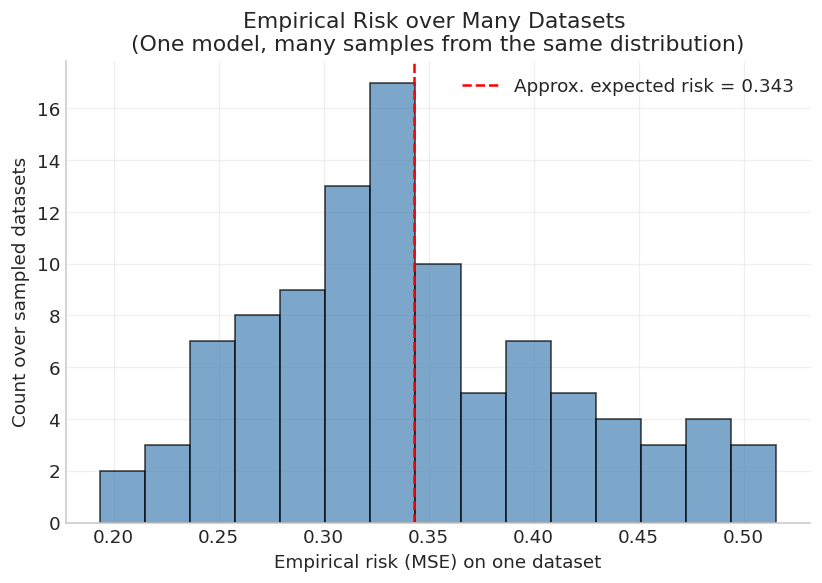

Each bar is an empirical risk value on one dataset.
The red dashed line approximates the expected risk (average over many possible datasets).


In [2]:
# Visualization: Expected vs Empirical Risk (Conceptual Simulation)

# We simulate a "true" quadratic relationship with noise
true_w0 = 1.0
true_w1 = 2.0
noise_std = 0.5

rng = np.random.default_rng(42)

def sample_dataset(n=50):
    x = rng.uniform(-2, 2, size=n)
    y = true_w0 + true_w1 * x + rng.normal(0, noise_std, size=n)
    return x, y

# Fixed candidate model (slightly wrong parameters)
model_w0 = 0.8
model_w1 = 1.8

def mse_loss(w0, w1, x, y):
    y_pred = w0 + w1 * x
    return np.mean((y_pred - y) ** 2)

# Approximate expected risk by averaging empirical risks over many sampled datasets
num_datasets = 100
emp_risks = []

for _ in range(num_datasets):
    x_s, y_s = sample_dataset(n=50)
    emp_risks.append(mse_loss(model_w0, model_w1, x_s, y_s))

approx_expected_risk = np.mean(emp_risks)

plt.figure(figsize=(8, 5))
plt.hist(emp_risks, bins=15, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(approx_expected_risk, color='red', linestyle='--', label=f"Approx. expected risk = {approx_expected_risk:.3f}")
plt.xlabel('Empirical risk (MSE) on one dataset')
plt.ylabel('Count over sampled datasets')
plt.title('Empirical Risk over Many Datasets \n(One model, many samples from the same distribution)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Each bar is an empirical risk value on one dataset.")
print("The red dashed line approximates the expected risk (average over many possible datasets).")

## Логістична регресія як ERM для класифікації

У Лабораторній 1 ви реалізували **логістичну регресію**. Тут ми явно пов'яжемо її з рамкою ERM.

### Модель і простір гіпотез

Для бінарної класифікації з мітками $y \in \{0, 1\}$:
- Лінійний скор: $z = w^\top x + b$
- Передбачена ймовірність класу 1: $$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$
- Простір гіпотез $\mathcal{H}$: усі лінійні розділяючі поверхні з логістичним зв'язком (logistic link)

### Логістична втрата (бінарна крос-ентропія)

Для одного прикладу $(x, y)$ з передбаченою ймовірністю $\hat{y}$:

$$L(y, \hat{y}) = -\big[y \log(\hat{y}) + (1-y) \log(1-\hat{y})\big]$$

Для датасету $\{(x_i, y_i)\}_{i=1}^n$ **емпіричний ризик** має вигляд:

$$R_{\text{emp}}(w, b) = \frac{1}{n} \sum_{i=1}^n -\big[y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)\big]$$

де $\hat{y}_i = \sigma(w^\top x_i + b)$.

### Чому логістична втрата для класифікації?

- Повертає **ймовірності** в діапазоні від 0 до 1.
- Дуже сильно штрафує **впевнені хибні передбачення**.
- Має хороші властивості для оптимізації (опукла, гладка за $(w, b)$).

### Приклади з індустрії

- **Прогноз відтоку (churn prediction)**: $y=1$, якщо клієнт піде протягом наступних 30 днів. Логістична регресія моделює $P(\text{churn} \mid x)$ і навчається шляхом мінімізації логістичної втрати.
- **Виявлення шахрайства**: $y=1$, якщо транзакція шахрайська. Ймовірнісний вихід моделі використовується в ризик-орієнтованих правилах прийняття рішень.
- **CTR (click-through rate)**: $y=1$, якщо користувач клікнув на рекламу. Логістична модель наближує $P(\text{click} \mid x)$ і оптимізується за крос-ентропійною втратою.

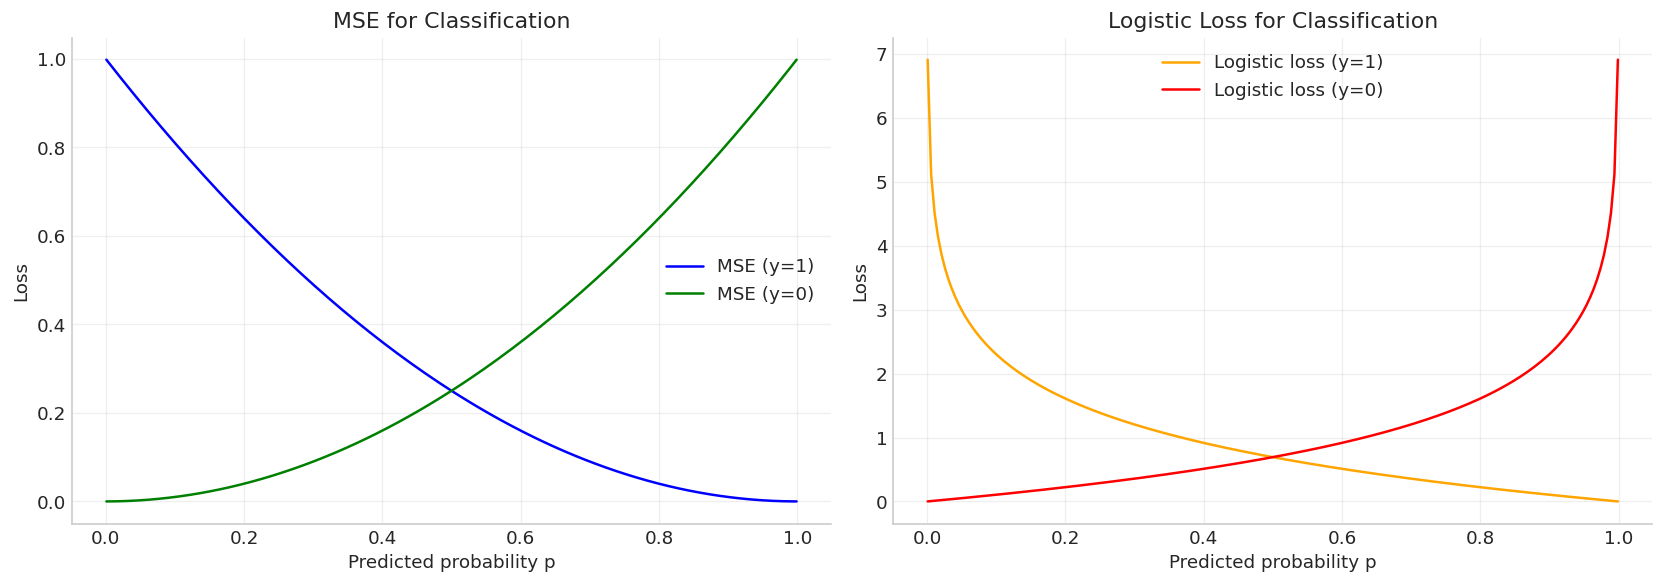

Observe how logistic loss goes to infinity for confident wrong predictions (p→0 when y=1, p→1 when y=0),
while MSE stays bounded. This is one reason logistic loss is preferred for classification.


In [3]:
# Visualization: MSE vs Logistic Loss for Classification

# Simple 1D classification: y in {0,1}, predicted probability p in [0,1]

p_vals = np.linspace(0.001, 0.999, 200)

# True label y = 1 and y = 0
y1 = 1
y0 = 0

mse_y1 = (p_vals - y1) ** 2
mse_y0 = (p_vals - y0) ** 2

log_loss_y1 = -np.log(p_vals)
log_loss_y0 = -np.log(1 - p_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(p_vals, mse_y1, label='MSE (y=1)', color='blue')
axes[0].plot(p_vals, mse_y0, label='MSE (y=0)', color='green')
axes[0].set_xlabel('Predicted probability p')
axes[0].set_ylabel('Loss')
axes[0].set_title('MSE for Classification')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(p_vals, log_loss_y1, label='Logistic loss (y=1)', color='orange')
axes[1].plot(p_vals, log_loss_y0, label='Logistic loss (y=0)', color='red')
axes[1].set_xlabel('Predicted probability p')
axes[1].set_ylabel('Loss')
axes[1].set_title('Logistic Loss for Classification')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observe how logistic loss goes to infinity for confident wrong predictions (p→0 when y=1, p→1 when y=0),")
print("while MSE stays bounded. This is one reason logistic loss is preferred for classification.")

## Функції втрат: властивості та типові застосування

Функції втрат вимірюють, наскільки наші передбачення є «неправильними». Важливі властивості:

### 1. Опуклість

Функція втрат є **опуклою**, якщо:
$$\ell(\lambda f_1(x) + (1-\lambda) f_2(x), y) \leq \lambda \ell(f_1(x), y) + (1-\lambda) \ell(f_2(x), y)$$

**Чому це важливо**:
- Опуклі втрати мають єдиний глобальний мінімум (простiше оптимізувати)
- Неопуклі втрати можуть мати багато локальних мінімумів (складніша оптимізація)

### 2. Гладкість

Функція втрат є **гладкою**, якщо вона має неперервні похідні.

**Чому це важливо**:
- Гладкі втрати дозволяють застосовувати градієнтні методи (можемо обчислювати градієнти)
- Гладкість впливає на швидкість збіжності: для більш гладких функцій градієнтний спуск часто збігається швидше

### 3. Стійкість

Функція втрат є **стійкою**, якщо вона не надто чутлива до викидів.

**Чому це важливо**:
- У реальних даних часто є викиди (помилки, аномалії)
- Робастні втрати не дозволяють кільком «поганим» прикладам домінувати в процесі оптимізації

### Узагальнювальна таблиця з прикладами з індустрії

| Втрата | Опукла? | Гладка? | Стійка? | Типові застосування | Приклад сценарію |
|--------|---------|---------|-----------|----------------------|-------------------|
| MSE (L2) | Так | Так | Ні | Регресія по неперервних тарґетах | Прогноз щоденного енергоспоживання, передбачення доходу |
| MAE (L1) | Так | Ні | Так | Робастна регресія | Прогноз часу доставки, де кілька сильних затримок не повинні домінувати |
| Логістична / крос-ентропія | Так | Так | Помірно | Бінарна / багатокласова класифікація | Прогноз відтоку, виявлення шахрайства, прогноз CTR |
| Huber | Так | Так | Так (для великих помилок) | Регресія з наявними викидами | Дані сенсорів на виробництві з поодинокими «спайками» |

У наступній клітинці ми візуалізуємо кілька таких функцій втрат.

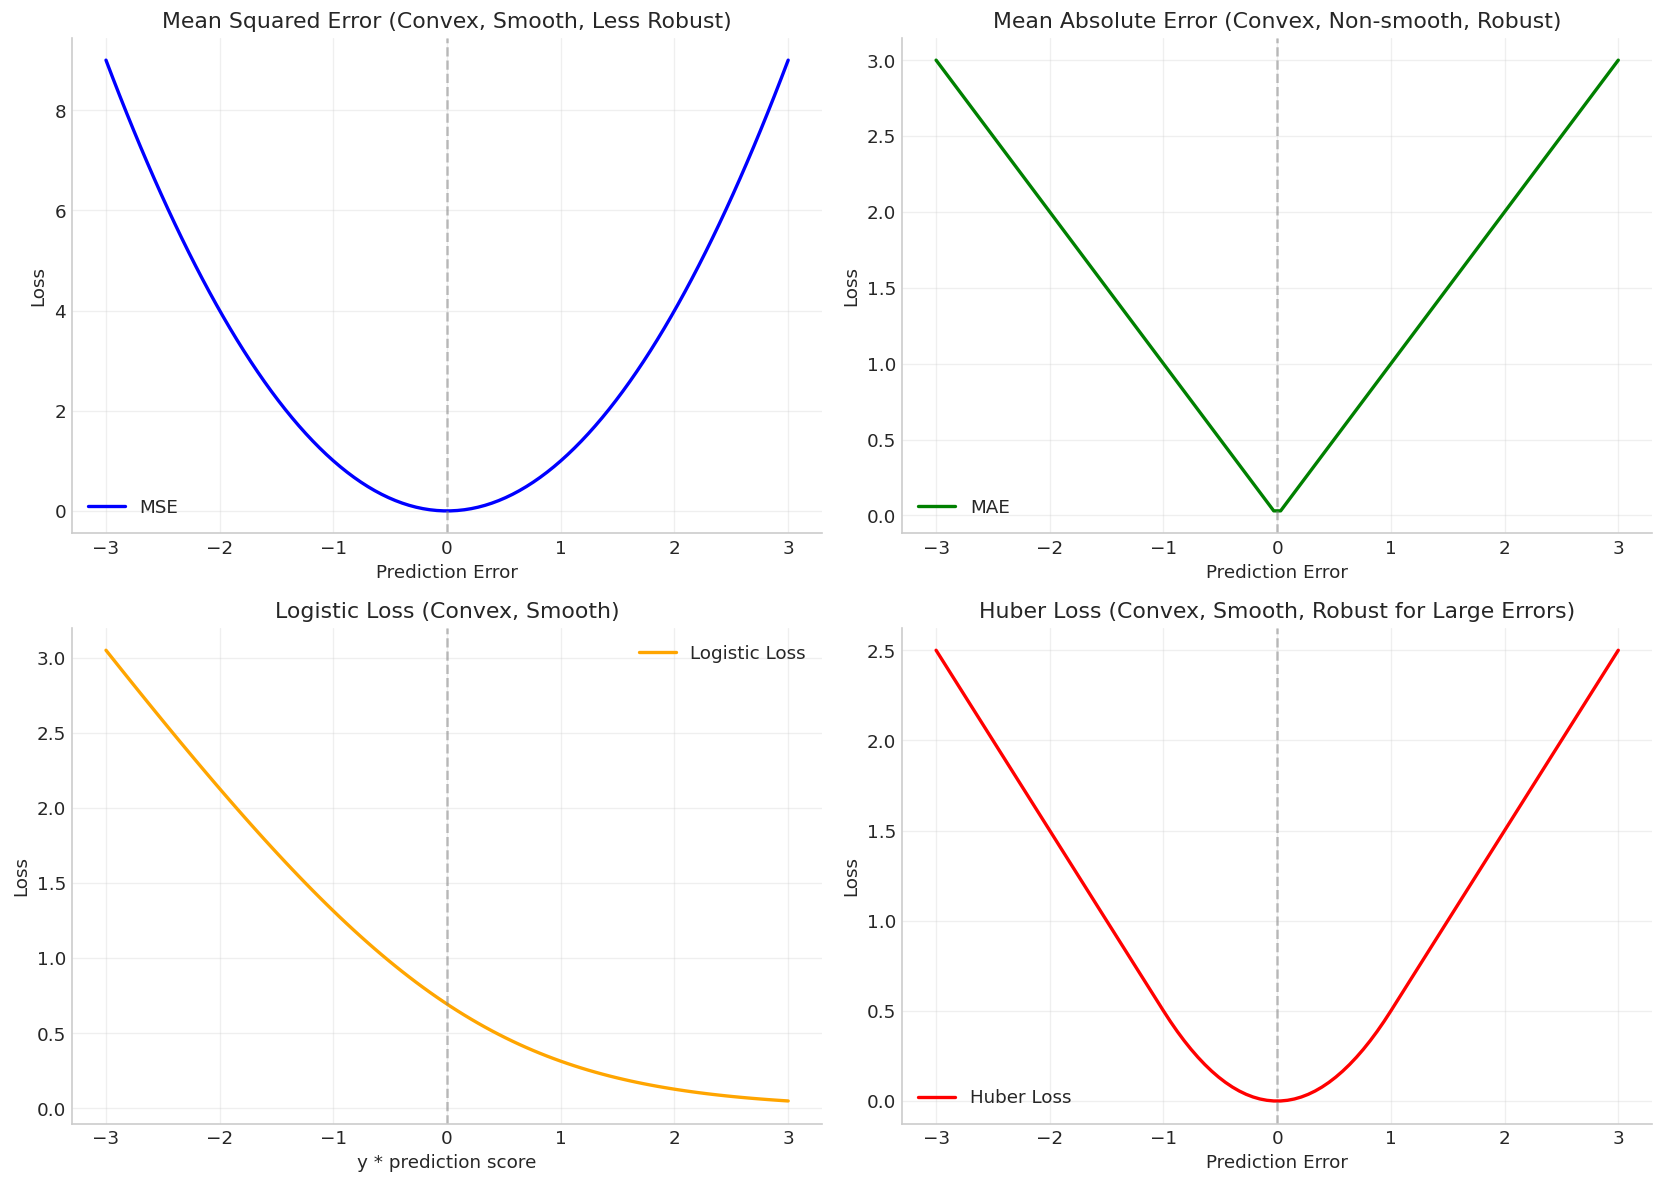

Key observations:
- MSE: Penalizes large errors quadratically (sensitive to outliers)
- MAE: Linear penalty (robust but non-smooth at zero)
- Logistic Loss: Smooth, convex, designed for probabilities in classification
- Huber Loss: Combines MSE (small errors) and MAE (large errors) for robustness


In [4]:
# Visualization: Common Loss Functions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Generate prediction errors
errors = np.linspace(-3, 3, 100)

# Mean Squared Error (MSE)
mse = errors**2
axes[0, 0].plot(errors, mse, label='MSE', linewidth=2, color='blue')
axes[0, 0].set_xlabel('Prediction Error')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Mean Squared Error (Convex, Smooth, Less Robust)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# Mean Absolute Error (MAE) - More robust
mae = np.abs(errors)
axes[0, 1].plot(errors, mae, label='MAE', linewidth=2, color='green')
axes[0, 1].set_xlabel('Prediction Error')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Mean Absolute Error (Convex, Non-smooth, Robust)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# Logistic Loss (for binary classification)
logistic_loss_curve = np.log(1 + np.exp(-errors))
axes[1, 0].plot(errors, logistic_loss_curve, label='Logistic Loss', linewidth=2, color='orange')
axes[1, 0].set_xlabel('y * prediction score')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Logistic Loss (Convex, Smooth)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
axes[1, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# Huber Loss (robust alternative to MSE)
delta = 1.0
huber_loss = np.where(np.abs(errors) <= delta, 
                      0.5 * errors**2, 
                      delta * (np.abs(errors) - 0.5 * delta))
axes[1, 1].plot(errors, huber_loss, label='Huber Loss', linewidth=2, color='red')
axes[1, 1].set_xlabel('Prediction Error')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Huber Loss (Convex, Smooth, Robust for Large Errors)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()
axes[1, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Key observations:")
print("- MSE: Penalizes large errors quadratically (sensitive to outliers)")
print("- MAE: Linear penalty (robust but non-smooth at zero)")
print("- Logistic Loss: Smooth, convex, designed for probabilities in classification")
print("- Huber Loss: Combines MSE (small errors) and MAE (large errors) for robustness")

## Градієнтний спуск як загальний метод оптимізації

**Градієнтний спуск** - це робоча конячка оптимізації в машинному навчанні.

### Алгоритм (високий рівень)

Нехай маємо функцію втрат $L(\theta)$, де $\theta$ - параметри моделі:

1. **Ініціалізувати** параметри $\theta_0$ (наприклад, випадково або нулями)
2. **Повторювати** до збіжності:
   $$\theta_{t+1} = \theta_t - \alpha \, \nabla_\theta L(\theta_t)$$
   де $\alpha$ - **швидкість навчання** (крок оновлення)
3. **Зупинити**, коли виконується критерій збіжності (наприклад, втрата перестає зменшуватися, норма градієнта стає малою).

### Псевдокод (рецепт)

```text
initialize theta
repeat:
    predictions = model(theta, X)
    loss = compute_loss(predictions, y)
    grad = gradient_of_loss_wrt_theta(theta)
    theta = theta - learning_rate * grad
until convergence
```

### Інтуїція

- **Градієнт** $\nabla_\theta L(\theta)$ вказує в напрямку найшвидшого **збільшення** втрати.
- **Негативний градієнт** $-\nabla_\theta L(\theta)$ вказує в напрямку найшвидшого **зменшення** втрати.
- Градієнтний спуск робить невеликі кроки в напрямку, який найшвидше зменшує втрату.

Далі ми розглянемо невеличкий числовий приклад."}},{

In [5]:
# Worked Example: One Gradient Descent Step in 2D

# Simple quadratic loss in 2D: L(theta) = (theta1 - 1)^2 + 2*(theta2 - 2)^2

def loss(theta):
    theta1, theta2 = theta
    return (theta1 - 1)**2 + 2 * (theta2 - 2)**2


def grad(theta):
    theta1, theta2 = theta
    dL_dtheta1 = 2 * (theta1 - 1)
    dL_dtheta2 = 4 * (theta2 - 2)
    return np.array([dL_dtheta1, dL_dtheta2])

# Start at an initial point
theta0 = np.array([3.0, 0.0])
alpha = 0.1

L0 = loss(theta0)
g0 = grad(theta0)

theta1 = theta0 - alpha * g0
L1 = loss(theta1)

print(f"Initial theta0 = {theta0}, loss L(theta0) = {L0:.3f}, grad = {g0}")
print(f"After one step with alpha = {alpha}:")
print(f"theta1 = {theta1}, loss L(theta1) = {L1:.3f}")

Initial theta0 = [3. 0.], loss L(theta0) = 12.000, grad = [ 4. -8.]
After one step with alpha = 0.1:
theta1 = [2.6 0.8], loss L(theta1) = 5.440


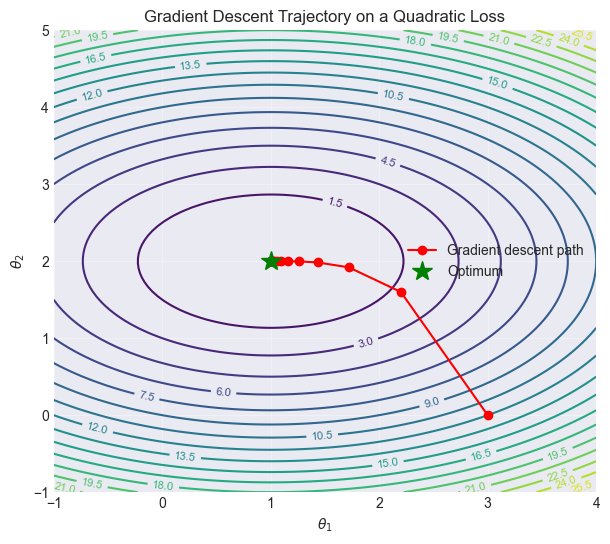

The red path shows how gradient descent moves across the loss surface towards the optimum.


In [9]:
# Visualization: Gradient Descent Trajectory on Contours

# Reuse loss and grad from previous cell

theta_opt = np.array([1.0, 2.0])

# Create grid for contour plot
t1 = np.linspace(-1, 4, 100)
t2 = np.linspace(-1, 5, 100)
T1, T2 = np.meshgrid(t1, t2)
L_grid = (T1 - 1)**2 + 2 * (T2 - 2)**2

# Run gradient descent to get a trajectory
alpha = 0.2
num_steps = 15
traj = [theta0.copy()]
theta = theta0.copy()

for _ in range(num_steps):
    theta = theta - alpha * grad(theta)
    traj.append(theta.copy())

traj = np.array(traj)

plt.figure(figsize=(7, 6))
cs = plt.contour(T1, T2, L_grid, levels=20, cmap='viridis')
plt.clabel(cs, inline=True, fontsize=8)
plt.plot(traj[:, 0], traj[:, 1], 'o-', color='red', label='Gradient descent path')
plt.plot(theta_opt[0], theta_opt[1], 'g*', markersize=15, label='Optimum')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title('Gradient Descent Trajectory on a Quadratic Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("The red path shows how gradient descent moves across the loss surface towards the optimum.")

## Пакетний, стохастичний та міні-пакетний градієнтний спуск

### Пакетний градієнтний спуск

**Batch gradient descent** (пакетний градієнтний спуск) використовує всю тренувальну вибірку для обчислення градієнта:

$$\theta_{t+1} = \theta_t - \alpha \, \frac{1}{n} \sum_{i=1}^n \nabla_\theta \, \ell(f(x_i), y_i)$$

**Властивості**:
- **Плюси**: точний градієнт (градієнт емпіричного ризику), детермінованість
- **Мінуси**: повільний для великих датасетів, потребує багато пам'яті, не може стартувати, поки всі дані не завантажені

**Коли використовується на практиці**: невеликі датасети, опуклі задачі, або коли потрібні точні градієнти для аналізу.

### Стохастичний градієнтний спуск (SGD)

**Stochastic gradient descent** використовує один випадковий приклад на ітерацію:

$$\theta_{t+1} = \theta_t - \alpha \, \nabla_\theta \, \ell(f(x_{i_t}), y_{i_t})$$

де $i_t$ - випадково вибраний індекс.

**Властивості**:
- **Плюси**: дуже швидкі оновлення, можна обробляти потоки даних, здатен «вибиратися» з дрібних локальних мінімумів
- **Мінуси**: шумні градієнти, крива втрати «зубчаста», часто потрібні складні схеми для learning rate

**Контекст в індустрії**: онлайн-навчання для виявлення шахрайства або ранжування реклами, де події приходять безперервно.

### Градієнтний спуск з міні-пакетами

**Mini-batch gradient descent** використовує невеликий випадковий пакет $B$ (наприклад, 32, 64, 256) на кожній ітерації:

$$\theta_{t+1} = \theta_t - \alpha \, \frac{1}{|B|} \sum_{i \in B} \nabla_\theta \, \ell(f(x_i), y_i)$$

**Властивості**:
- Баланс між швидкістю та стабільністю
- Добре паралелізується на GPU
- Де-факто стандарт у глибокому навчанні

**Контекст в індустрії**: навчання великих нейронних мереж для рекомендаційних систем, пошукового ранжування або моделей комп'ютерного зору на мільйонах прикладів.

У наступній клітинці ми порівняємо їхні траєкторії оптимізації та криві втрат.

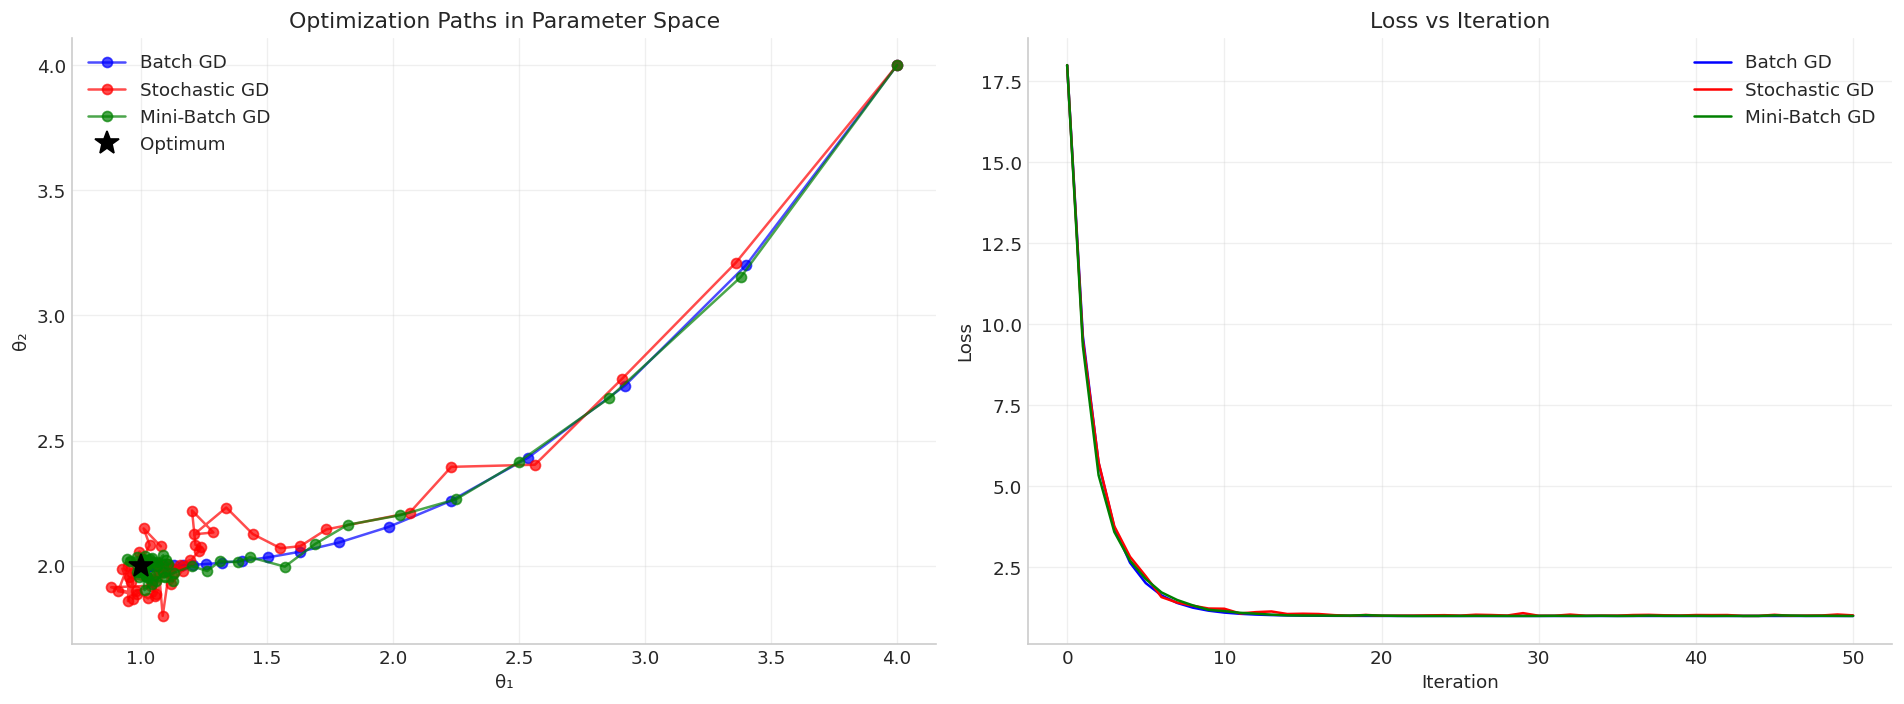

Batch GD: smooth, stable convergence.
SGD: noisy but can still make progress.
Mini-batch: compromise between stability and speed.


In [6]:
# Visualization: Batch vs Stochastic vs Mini-Batch Convergence (Paths and Loss)

def quad_loss(theta):
    return (theta[0] - 1)**2 + 2 * (theta[1] - 2)**2 + 1

def quad_grad(theta):
    return np.array([2 * (theta[0] - 1), 4 * (theta[1] - 2)])

def noisy_grad(theta, noise_level=0.5):
    return quad_grad(theta) + np.random.normal(0, noise_level, size=2)

# Initialize
theta_batch = np.array([4.0, 4.0])
theta_sgd = np.array([4.0, 4.0])
theta_minibatch = np.array([4.0, 4.0])

learning_rate = 0.1
n_iterations = 50

traj_batch = [theta_batch.copy()]
traj_sgd = [theta_sgd.copy()]
traj_minibatch = [theta_minibatch.copy()]

loss_batch = [quad_loss(theta_batch)]
loss_sgd = [quad_loss(theta_sgd)]
loss_minibatch = [quad_loss(theta_minibatch)]

for i in range(n_iterations):
    # Batch: exact gradient
    theta_batch = theta_batch - learning_rate * quad_grad(theta_batch)
    traj_batch.append(theta_batch.copy())
    loss_batch.append(quad_loss(theta_batch))
    
    # SGD: high noise
    theta_sgd = theta_sgd - learning_rate * noisy_grad(theta_sgd, noise_level=0.8)
    traj_sgd.append(theta_sgd.copy())
    loss_sgd.append(quad_loss(theta_sgd))
    
    # Mini-batch: lower noise
    theta_minibatch = theta_minibatch - learning_rate * noisy_grad(theta_minibatch, noise_level=0.3)
    traj_minibatch.append(theta_minibatch.copy())
    loss_minibatch.append(quad_loss(theta_minibatch))

# Plot parameter-space trajectories
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for traj, title, color in [
    (np.array(traj_batch), 'Batch GD', 'blue'),
    (np.array(traj_sgd), 'Stochastic GD', 'red'),
    (np.array(traj_minibatch), 'Mini-Batch GD', 'green'),
]:
    axes[0].plot(traj[:, 0], traj[:, 1], 'o-', color=color, alpha=0.7, label=title)

axes[0].plot(1, 2, 'k*', markersize=15, label='Optimum')
axes[0].set_xlabel('θ₁')
axes[0].set_ylabel('θ₂')
axes[0].set_title('Optimization Paths in Parameter Space')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss vs iteration
iters = np.arange(len(loss_batch))
axes[1].plot(iters, loss_batch, label='Batch GD', color='blue')
axes[1].plot(iters, loss_sgd, label='Stochastic GD', color='red')
axes[1].plot(iters, loss_minibatch, label='Mini-Batch GD', color='green')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs Iteration')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Batch GD: smooth, stable convergence.")
print("SGD: noisy but can still make progress.")
print("Mini-batch: compromise between stability and speed.")

## Оптимізація vs узагальнення

В машинному навчанні ми завжди балансуємо між двома цілями:

- **Оптимізація**: добре мінімізувати **тренувальну втрату** (емпіричний ризик)
- **Узагальнення**: добре працювати на **нових, невідомих даних** (низький очікуваний ризик)

Формально:
- Оптимізація фокусується на $R_{\text{emp}}(f)$ - середній втраті на train.
- Узагальнення фокусується на $R(f)$ - середній втраті по істинному розподілу даних.

Щоб зрозуміти зв'язок між ними, розглянемо **компроміс «bias–variance»**.

------------------------------------------------------------------------

### 1. Формула компромісу «bias–variance»

$$
\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}
$$

Це розклад очікуваної квадратичної помилки моделі в задачі регресії.

Нехай істинна залежність має вигляд:

$$
y = f(x) + \varepsilon
$$

де шум:

$$
\varepsilon \sim \mathcal{N}(0, \sigma^2)
$$

Модель дає прогноз $\hat{f}(x)$, і ми мінімізуємо

$$
\mathbb{E}\big[(y - \hat{f}(x))^2\big].
$$

Після розкладу отримаємо:

$$
\mathbb{E}\big[(y - \hat{f}(x))^2\big] =
(\mathbb{E}[\hat{f}(x)] - f(x))^2
+
\mathbb{E}[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2]
+ 
\sigma^2.
$$

------------------------------------------------------------------------

### 2. Компоненти помилки

#### Bias (систематична помилка)

$$
\text{Bias}(x) = \mathbb{E}[\hat{f}(x)] - f(x)
$$

**Інтуїція:** модель занадто проста і не може відтворити структуру даних (недонавчання).

Ознаки:
- стабільні прогнози
- систематично неправильні значення
- високі втрати і на train, і на validation/test

------------------------------------------------------------------------

#### Variance (дисперсія)

$$
\text{Variance}(x) = \mathbb{E}[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2]
$$

**Інтуїція:** модель дуже чутлива до конкретної навчальної вибірки (перенавчання).

Ознаки:
- дуже малий train error
- значно більший test/validation error
- модель «запам'ятовує» шум у даних

------------------------------------------------------------------------

#### Irreducible Error (невикорінний шум)

$$
\sigma^2 = \text{Var}(\varepsilon)
$$

Це шум у самих даних (вимірювальні похибки, людський фактор, випадковість).
Його неможливо зменшити жодною моделлю.

------------------------------------------------------------------------

### 3. Чому це компроміс?

Зі зростанням **складності моделі** (більше параметрів, глибші мережі, вищий степінь полінома):

- **Bias** зазвичай **зменшується** - модель краще підлаштовується під складні закономірності.
- **Variance** зазвичай **зростає** - модель стає більш чутливою до шуму конкретної вибірки.

У результаті **test error** має U-подібну форму залежно від складності моделі:

- Зліва: надто проста модель → високий bias (недонавчання).
- Справа: надто складна модель → висока variance (перенавчання).
- Посередині: **оптимальна модель** - мінімум сумарної помилки.

------------------------------------------------------------------------

### 4. Практична діагностика (через train vs validation)

- Якщо **train ≈ test** і **обидва великі** → **високий bias**, недонавчання.
- Якщо **train малий**, а **test великий** → **висока variance**, перенавчання.
- Якщо **train і test невеликі та близькі** → хороший баланс між bias і variance, **гарне узагальнення**.

------------------------------------------------------------------------

### 5. Ключова ідея для оптимізації

Неможливо одночасно мінімізувати і **систематичну помилку (bias)**, і **чутливість до вибірки (variance)**.
Під час оптимізації ми не просто «знижуємо loss на train», а фактично **рухаємось по осі складності моделі**, намагаючись знайти баланс між цими двома типами помилок.

У наступній клітинці ми побачимо це на прикладі динаміки **train vs validation втрат** для недонавчання, гарного узагальнення та перенавчання.

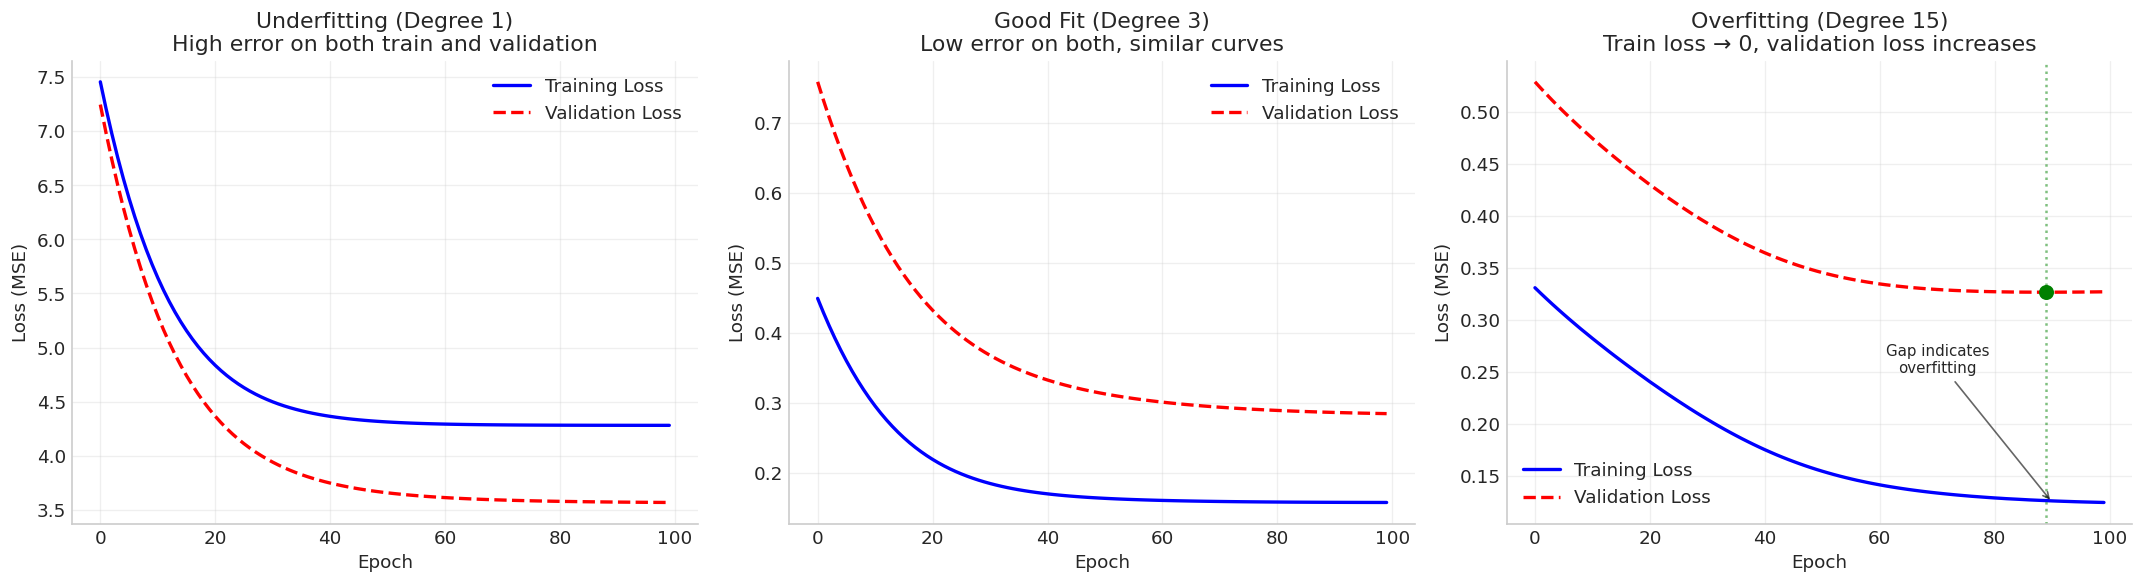

Key observations:
- Underfitting: Both losses are high and decrease slowly (model too simple)
- Good fit: Both losses decrease and converge to similar low values
- Overfitting: Training loss decreases to near zero, but validation loss increases after a point

In practice, you would monitor validation loss during training and stop when it starts increasing (early stopping).
The green dot in the overfitting plot shows where early stopping would occur (minimum validation loss).


In [9]:
# Visualization: Train vs Validation Loss Over Epochs
# Demonstrates underfitting, good fit, and overfitting through training dynamics

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Generate synthetic data with a true quadratic relationship
np.random.seed(42)
X_train = np.linspace(0, 4, 30).reshape(-1, 1)
y_train = 2 * X_train.flatten() + 1.5 * X_train.flatten()**2 + np.random.normal(0, 0.5, 30)

X_val = np.linspace(0, 4, 100).reshape(-1, 1)
y_val = 2 * X_val.flatten() + 1.5 * X_val.flatten()**2 + np.random.normal(0, 0.5, 100)

# Simulate training over epochs for different model complexities
# We'll use polynomial degrees to represent complexity
degrees = [1, 3, 15]  # Underfit, good fit, overfit
epochs = 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, degree in enumerate(degrees):
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    
    # Simulate training by gradually fitting the model
    # We use Ridge regression with decreasing regularization to simulate
    # the effect of training iterations (as regularization decreases, model fits more)
    train_losses = []
    val_losses = []
    
    # Simulate training progression
    for epoch in range(epochs):
        # Gradually reduce regularization to simulate learning
        # (This simulates the effect of gradient descent: as training progresses,
        # the model fits the training data better, which can lead to overfitting)
        alpha_reg = 10.0 * np.exp(-epoch / 20)  # Regularization decreases over time
        
        model = Ridge(alpha=alpha_reg)
        model.fit(X_train_poly, y_train)
        
        y_train_pred = model.predict(X_train_poly)
        y_val_pred = model.predict(X_val_poly)
        
        train_loss = mean_squared_error(y_train, y_train_pred)
        val_loss = mean_squared_error(y_val, y_val_pred)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
    
    # Plot train vs validation loss
    epochs_range = np.arange(epochs)
    axes[idx].plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2)
    axes[idx].plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss (MSE)')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()
    
    if degree == 1:
        axes[idx].set_title(f'Underfitting (Degree {degree})\nHigh error on both train and validation')
    elif degree == 3:
        axes[idx].set_title(f'Good Fit (Degree {degree})\nLow error on both, similar curves')
    else:
        axes[idx].set_title(f'Overfitting (Degree {degree})\nTrain loss → 0, validation loss increases')
    
    # Add gap annotation for overfitting case
    if degree == 15:
        min_val_idx = np.argmin(val_losses)
        axes[idx].annotate('Gap indicates\noverfitting', 
                          xy=(epochs-10, train_losses[-1]), 
                          xytext=(epochs-30, train_losses[-1]*2),
                          arrowprops=dict(arrowstyle='->', color='black', alpha=0.6),
                          fontsize=9, ha='center')
        # Mark the best validation point (where early stopping would occur)
        axes[idx].plot(min_val_idx, val_losses[min_val_idx], 'go', markersize=8, label='Best validation')
        axes[idx].axvline(min_val_idx, color='green', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("Key observations:")
print("- Underfitting: Both losses are high and decrease slowly (model too simple)")
print("- Good fit: Both losses decrease and converge to similar low values")
print("- Overfitting: Training loss decreases to near zero, but validation loss increases after a point")
print("\nIn practice, you would monitor validation loss during training and stop when it starts increasing (early stopping).")
print("The green dot in the overfitting plot shows where early stopping would occur (minimum validation loss).")

## Підсумок

На цій лекції ми розглянули:

- Теоретичне підґрунтя ключових алгоритмів
- Геометричну інтуїцію та математичні деривації
- Практичні приклади та інтерактивні демонстрації